In [188]:
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt
import random

In [189]:
data = genfromtxt("advertising.csv", delimiter=',', skip_header=1)
N = data.shape[0]
X = data[:, :3]
y = data[:, 3:]
print(X[:5])
print(y[:5])

[[230.1  37.8  69.2]
 [ 44.5  39.3  45.1]
 [ 17.2  45.9  69.3]
 [151.5  41.3  58.5]
 [180.8  10.8  58.4]]
[[22.1]
 [10.4]
 [12. ]
 [16.5]
 [17.9]]


In [190]:
def mean_normalization(X):
    N = len(X)
    maxi = np.max(X)
    mini = np.min(X)
    avg = np.mean(X)
    X = (X - avg) / (maxi - mini)
    X_b = np.c_[np.ones((N, 1)), X]
    return X_b, maxi, mini, avg

X_b, maxi, mini, avg = mean_normalization(X)

In [191]:
def initialize_params(length):
    res = []
    for i in range(length+1):
        x = random.gauss(mu=0.0, sigma=0.01)
        res.append(x)
    return res;

In [192]:
def prediction(N, d_plus1, w, x, b):
    res = []
    for i in range(N):
        tmp = 0
        for j in range(d_plus1):
            tmp += (w[j] * x[i][j])
        tmp += b
        res.append(tmp)
    return res

In [193]:
def MSE(N, pred, y):
    res = 0
    for i in range(N):
        res += (pred[i] - y[i]) * (pred[i] - y[i])
    res /= N
    return res

In [194]:
def derivative(n, d_plus1, x, pred, y):
    res = np.zeros(d_plus1)

    for i in range(len(pred)):
        error = pred[i] - y[i]
        res += 2 * x[i] * error
    res /= n

    return res

def derivative_b(n, pred, y):
    res = 0
    mean = 0
    for i in range(len(pred)):
        mean += (pred[i] - y[i])
    mean /= n
    
    res = 2 * mean
    return res

In [195]:
def update(w, lr, gd):
    thetas = []
    for i in range(len(gd)):
        thetas.append(w[i] - lr * gd[i])
    return thetas

def update_b(b, lr, gd_b):
    return b - lr * gd_b

In [196]:
def batch_gradient_descent(X, y, n_epochs=100, learning_rate=0.01):
    N, d_plus1 = X_b.shape
    #print(N, d_plus1)
    # Step 1: Init parameters
    thetas = initialize_params(d_plus1)

    thetas_path = [thetas.copy()]
    losses = []

    for epoch in range(n_epochs):
        # Step 3: prediction
        pred = prediction(N, d_plus1, thetas, X, thetas[len(thetas)-1])
        # print("type:", type(pred))
        # print("shape:", np.shape(pred))
        # print("first:", pred[0])
        
        # Step 4: MSE loss
        mse = MSE(N, pred, y)
        #print("MSE: ",mse)
        
        # Step 5: gradient
        gd = derivative(N, d_plus1, X, pred, y)
        gd_b = derivative_b(N, pred, y)
        # print("gd: ", gd)
        
        # Step 6: update parameters
        thetas = update(thetas, learning_rate, gd)
        thetas[len(thetas)-1] = update_b(thetas[len(thetas)-1], learning_rate, gd_b)

        # log
        thetas_path.append(thetas.copy())
        losses.append(mse)

    return thetas_path, losses

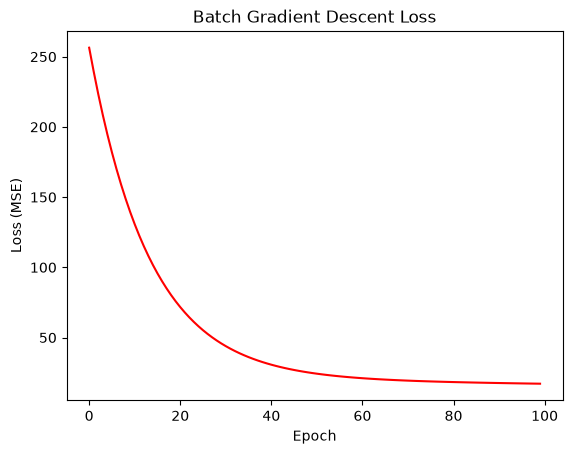

In [197]:
bgd_thetas, losses = batch_gradient_descent(X_b, y, n_epochs=100,
learning_rate=0.01)

# visualize
x_axis = list(range(100))
plt.plot(x_axis, losses[:100], color="r")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Batch Gradient Descent Loss")
plt.show()
